In [1]:
import pandas as pd

df = pd.DataFrame({
    "Age": [22, 25, 28, 30, 32, 35, 38, 40, 42, 45,
            47, 50, 52, 55, 58, 60, 62, 65, 80, 95],

    "Salary": [30000, 32000, 35000, 37000, 39000,
               42000, 45000, 47000, 50000, 53000,
               56000, 60000, 63000, 67000, 70000,
               74000, 78000, 82000, 180000, 300000],

    "Experience": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
                   11, 12, 13, 14, 15, 16, 17, 18, 30, 40]
})

print(df)

    Age  Salary  Experience
0    22   30000           1
1    25   32000           2
2    28   35000           3
3    30   37000           4
4    32   39000           5
5    35   42000           6
6    38   45000           7
7    40   47000           8
8    42   50000           9
9    45   53000          10
10   47   56000          11
11   50   60000          12
12   52   63000          13
13   55   67000          14
14   58   70000          15
15   60   74000          16
16   62   78000          17
17   65   82000          18
18   80  180000          30
19   95  300000          40


Column : Age
Count      : 20
Mean       : 48.05
Median     : 46.00
Mode       : 22
Minimum    : 22
Maximum    : 95
Q1         : 34.25
Q3         : 58.50
IQR        : 24.25
Lower Limit: -2.12
Upper Limit: 94.88
Std Dev    : 18.63
Outliers   : 1
19    95
Name: Age, dtype: int64


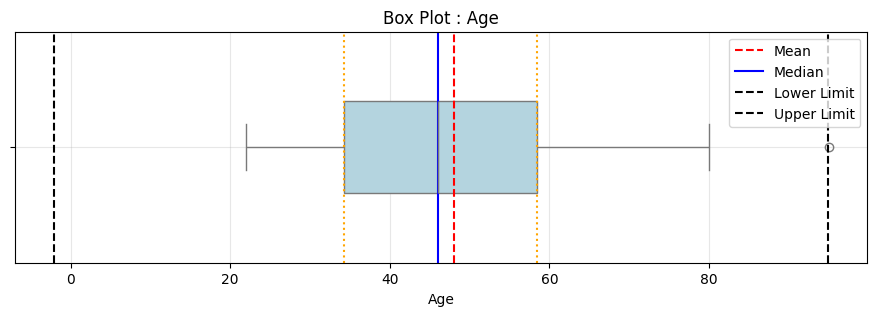

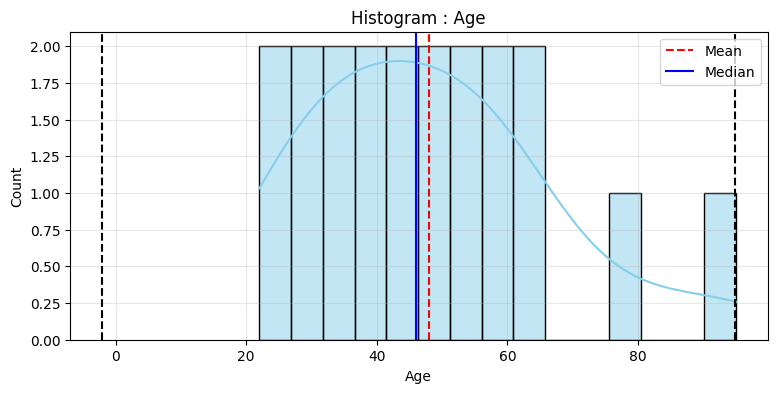

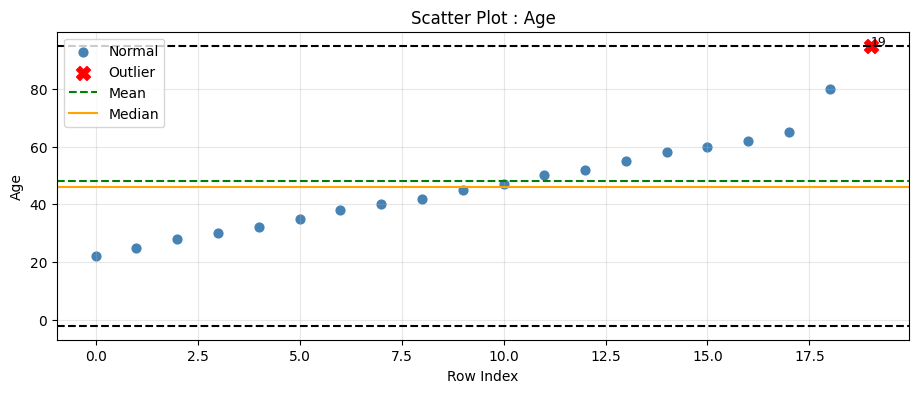

Column : Salary
Count      : 20
Mean       : 72000.00
Median     : 54500.00
Mode       : 30000
Minimum    : 30000
Maximum    : 300000
Q1         : 41250.00
Q3         : 71000.00
IQR        : 29750.00
Lower Limit: -3375.00
Upper Limit: 115625.00
Std Dev    : 62594.77
Outliers   : 2
18    180000
19    300000
Name: Salary, dtype: int64


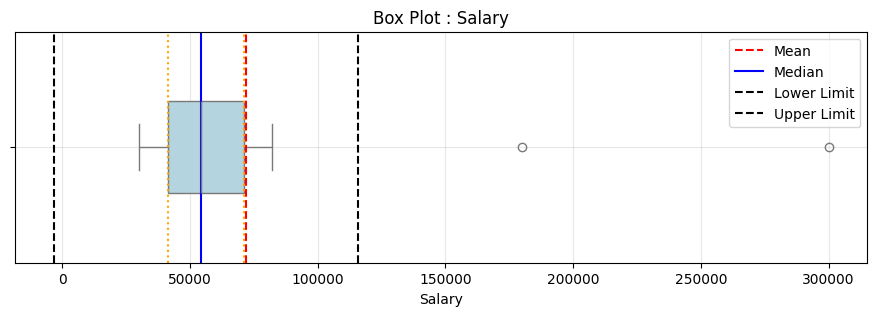

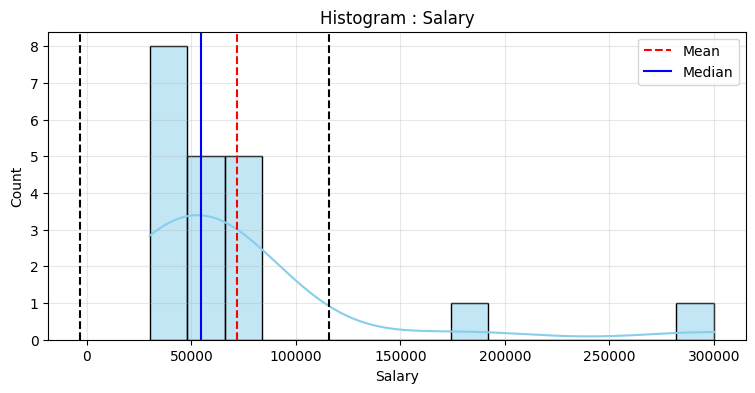

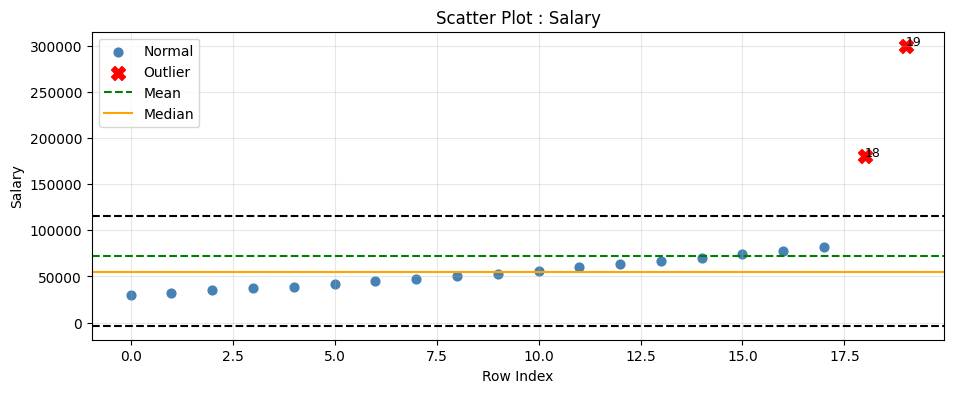

Column : Experience
Count      : 20
Mean       : 12.05
Median     : 10.50
Mode       : 1
Minimum    : 1
Maximum    : 40
Q1         : 5.75
Q3         : 15.25
IQR        : 9.50
Lower Limit: -8.50
Upper Limit: 29.50
Std Dev    : 9.47
Outliers   : 2
18    30
19    40
Name: Experience, dtype: int64


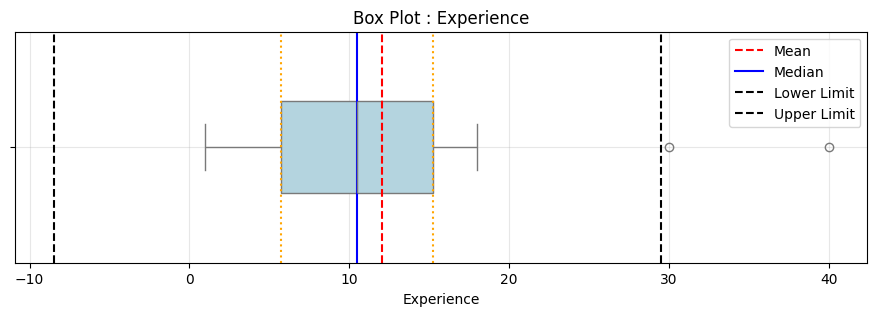

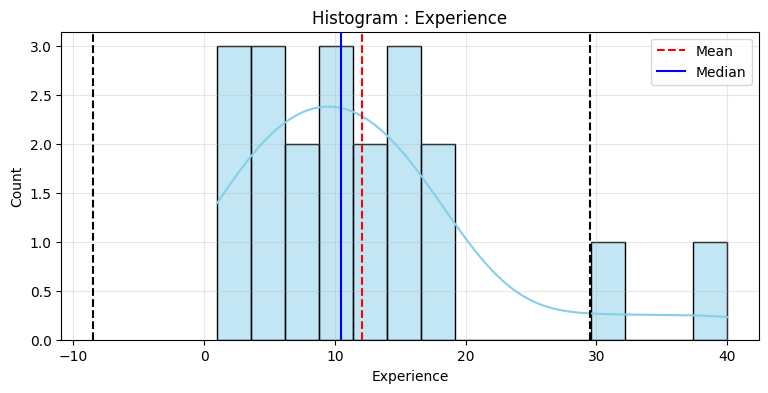

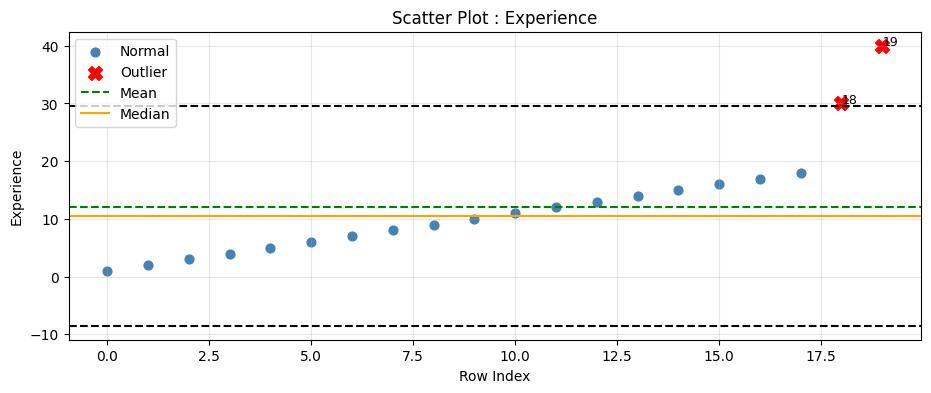

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:

    data = df[col].dropna()

    # ==========================================
    # Basic Statistics
    # ==========================================
    mean = data.mean()
    median = data.median()
    mode = data.mode().iloc[0]

    minimum = data.min()
    maximum = data.max()

    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    std = data.std()

    outliers = data[(data < lower) | (data > upper)]

    print("=" * 70)
    print(f"Column : {col}")
    print("=" * 70)
    print(f"Count      : {data.count()}")
    print(f"Mean       : {mean:.2f}")
    print(f"Median     : {median:.2f}")
    print(f"Mode       : {mode}")
    print(f"Minimum    : {minimum}")
    print(f"Maximum    : {maximum}")
    print(f"Q1         : {q1:.2f}")
    print(f"Q3         : {q3:.2f}")
    print(f"IQR        : {iqr:.2f}")
    print(f"Lower Limit: {lower:.2f}")
    print(f"Upper Limit: {upper:.2f}")
    print(f"Std Dev    : {std:.2f}")
    print(f"Outliers   : {len(outliers)}")

    if len(outliers):
        print(outliers)

    # =====================================================
    # BOX PLOT
    # =====================================================

    plt.figure(figsize=(11,3))

    sns.boxplot(
        x=data,
        color="lightblue",
        width=.4,
        whis=1.5
    )

    plt.axvline(mean,color="red",ls="--",label=f"Mean")
    plt.axvline(median,color="blue",label="Median")
    plt.axvline(q1,color="orange",ls=":")
    plt.axvline(q3,color="orange",ls=":")
    plt.axvline(lower,color="black",ls="--",label="Lower Limit")
    plt.axvline(upper,color="black",ls="--",label="Upper Limit")

    plt.title(f"Box Plot : {col}")
    plt.legend()
    plt.grid(alpha=.3)

    plt.show()

    # =====================================================
    # HISTOGRAM
    # =====================================================

    plt.figure(figsize=(9,4))

    sns.histplot(data,
                 bins=15,
                 kde=True,
                 color="skyblue")

    plt.axvline(mean,color="red",ls="--",label="Mean")
    plt.axvline(median,color="blue",label="Median")
    plt.axvline(lower,color="black",ls="--")
    plt.axvline(upper,color="black",ls="--")

    plt.title(f"Histogram : {col}")
    plt.legend()
    plt.grid(alpha=.3)

    plt.show()

    # =====================================================
    # SCATTER
    # =====================================================

    plt.figure(figsize=(11,4))

    normal = data[(data >= lower) & (data <= upper)]

    plt.scatter(
        normal.index,
        normal,
        color="steelblue",
        s=40,
        label="Normal"
    )

    if len(outliers):

        plt.scatter(
            outliers.index,
            outliers,
            color="red",
            s=100,
            marker="X",
            label="Outlier"
        )

        for idx, value in outliers.items():
            plt.text(idx, value, str(idx), fontsize=9)

    plt.axhline(mean,color="green",ls="--",label="Mean")
    plt.axhline(median,color="orange",label="Median")
    plt.axhline(lower,color="black",ls="--")
    plt.axhline(upper,color="black",ls="--")

    plt.title(f"Scatter Plot : {col}")
    plt.xlabel("Row Index")
    plt.ylabel(col)
    plt.legend()
    plt.grid(alpha=.3)

    plt.show()

cross-validation

In [1]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression

X = np.array([[234,8],[236,9],[233,18],[235,19],[232,2],
              [237,3],[234,20],[236,12],[233,14],[235,21]])
y = np.array([1.2,1.4,2.1,2.3,0.4,0.3,2.0,1.1,1.0,2.2])

model = LinearRegression()
kf = KFold(n_splits=5, shuffle=False)

scores = cross_val_score(model, X, y, cv=kf, scoring="neg_mean_absolute_error")
print("Fold MAEs:", -scores)
print("Average MAE:", -scores.mean())

Fold MAEs: [0.41695277 0.36839134 0.27589785 0.2588499  0.38541975]
Average MAE: 0.34110232425294107


In [2]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
print("Time-aware fold MAEs:", -scores)

Time-aware fold MAEs: [0.57758003 0.43364459 0.35423223 0.66019017 0.03371059]
